In [29]:
import pandas as pd
import numpy as np
import time
from time import time as t

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

In [30]:
df = pd.read_csv('/kaggle/input/datasets/diyaamaheshwari/tweetss/Tweets.csv')

# Select correct columns
df = df[['text', 'sentiment']]

# Rename for compatibility
df.rename(columns={'sentiment': 'airline_sentiment'}, inplace=True)

df.head()

,text,airline_sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [31]:
# Handle missing values
df = df.dropna(subset=['text'])

# Convert to string
df['text'] = df['text'].astype(str)

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['airline_sentiment'])

# Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

sequences = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(sequences, maxlen=100)

y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data ready ")

Data ready 


In [32]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [33]:
rnn_model = Sequential([
    Embedding(5000, 64, input_length=100),
    SimpleRNN(64),
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dense(3, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [34]:
lstm_model = Sequential([
    Embedding(5000, 64, input_length=100),
    LSTM(64),
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [35]:
start_time = time.time()

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

end_time = time.time()
rnn_time = end_time - start_time

print("RNN Training Time:", rnn_time)

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.4290 - loss: 1.0975 - val_accuracy: 0.5622 - val_loss: 0.9470 - learning_rate: 0.0010
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6916 - loss: 0.7691 - val_accuracy: 0.6559 - val_loss: 0.8202 - learning_rate: 0.0010
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8294 - loss: 0.4775 - val_accuracy: 0.6452 - val_loss: 0.9189 - learning_rate: 0.0010
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9318 - loss: 0.2424 - val_accuracy: 0.6336 - val_loss: 1.1071 - learning_rate: 5.0000e-04
RNN Training Time: 18.133853912353516


In [36]:
start = t()

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

end = t()
lstm_time = end - start

print("LSTM Training Time:", lstm_time)

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4757 - loss: 1.0205 - val_accuracy: 0.6773 - val_loss: 0.7581 - learning_rate: 0.0010
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7448 - loss: 0.6402 - val_accuracy: 0.6832 - val_loss: 0.7393 - learning_rate: 0.0010
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7892 - loss: 0.5411 - val_accuracy: 0.7030 - val_loss: 0.7376 - learning_rate: 0.0010
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8143 - loss: 0.4904 - val_accuracy: 0.6923 - val_loss: 0.7687 - learning_rate: 0.0010
Epoch 5/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8474 - loss: 0.4186 - val_accuracy: 0.6841 - val_loss: 0.8234 - learning_rate: 5.0000e-04
LSTM Training Time: 16.11681628227234


In [37]:
rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test, verbose=0)
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test, verbose=0)

print("\n===== FINAL RESULTS =====")
print(f"RNN Accuracy: {rnn_acc:.4f}")
print(f"LSTM Accuracy: {lstm_acc:.4f}")

print(f"RNN Time: {rnn_time:.2f} sec")
print(f"LSTM Time: {lstm_time:.2f} sec")

print(f"Accuracy Improvement: {(lstm_acc - rnn_acc)*100:.2f}%")


===== FINAL RESULTS =====
RNN Accuracy: 0.6601
LSTM Accuracy: 0.7051
RNN Time: 18.13 sec
LSTM Time: 16.12 sec
Accuracy Improvement: 4.49%


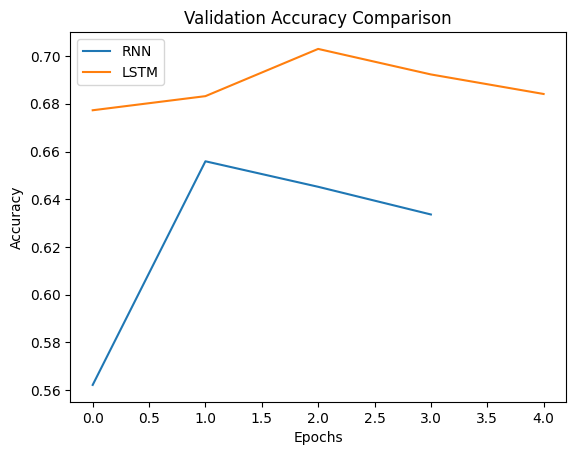

In [38]:
import matplotlib.pyplot as plt

plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()